In [14]:
import numpy as np
# import pandas as pd

import matplotlib.pyplot as plt
import re
from pathlib import Path
import string
import pickle

from functools import partial

In [15]:
# from imblearn.pipeline import Pipeline # supports for oversampling step
# from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    StratifiedKFold,
    GridSearchCV,
    cross_val_score,
    train_test_split)
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    ConfusionMatrixDisplay,
    roc_curve, 
    auc,
    average_precision_score,
    roc_auc_score,
    f1_score)


from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression  # TODO we can also use this
from sklearn.naive_bayes import BernoulliNB, MultinomialNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import f1_score

# from xgboost import XGBClassifier

from sklearn.decomposition import TruncatedSVD

# from imblearn.over_sampling import RandomOverSampler, SMOTE

from tqdm import tqdm

In [16]:
import torch
from transformers import CamembertTokenizer

import json
from huggingface_hub import login

with open("login_hf.json", "r") as f:
    login_hf = json.load(f)
login(token=login_hf["token"])


from transformers import CamembertForSequenceClassification, CamembertModel
import torch
import torch.nn as nn
from torch.optim import AdamW

from torch.utils.data import Dataset, DataLoader

In [17]:
# from rital.data import (
#     load_presidents,
#     load_presidents_unseen,
# )
# from rital.preprocessing import (
#     preprocess, 
#     vectorize,
#     compute_odds_ratio,
#     plot_frequencies,
#     plot_word_cloud
# )


from rital.presidents.analysis import (
    plot_roc_pr,
    ordered_train_test_split,
    plot_train_test_cm,
    TextStats
)

from rital.presidents.postprocessing import (
    smooth,
    plot_smoothing,
    calibrate_proba,
    adjust_threshold,
    adjust_proba,
    SmoothLogisticRegression
)
%load_ext autoreload
%autoreload 2

FILE_PRESIDENTS = "../../../data/presidents/presidents.utf8"
FILE_PRESIDENTS_UNSEEN = "../../../data/presidents/presidents-unseen.utf8"


# Functions for loading data
def load_presidents(file=FILE_PRESIDENTS) -> tuple[np.ndarray, np.ndarray]:
    """
    0 for Chirac
    1 for Mitterrand
    """
    texts = []
    labels = []
    with open(file) as f:
        for line in f.readlines():
            speaker, sentence = re.match(r"<\d+:\d+:(.)>\s*(.*)\n", line).groups()
            if speaker == "C":
                speaker = 0
            elif speaker == "M":
                speaker = 1
            else:
                # Something went wrong
                raise ValueError
            texts.append(sentence)
            labels.append(speaker)
    return np.array(texts), np.array(labels)


def load_presidents_unseen(file=FILE_PRESIDENTS_UNSEEN) -> list[str]:
    x = []
    with open(file) as f:
        for line in f.readlines():
            sentence = re.match(r"<\d+:\d+>\s*(.*)\n", line).group(1)
            x.append(sentence)
    return x

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Load and split data

In [18]:
X_train_full, y_train_full = load_presidents()
X_test = load_presidents_unseen()
label2name = {
    0 : "Chirac",
    1 : "Mitterrand"
}

# Keep track of indices to restore the time order
indices = np.arange(len(X_train_full))

# Step 1: randomly select which indices go to train/val
train_idx, val_idx = train_test_split(
    indices,
    test_size=0.2,
    # random_state=1,
    shuffle=False,
    # stratify=y_train_full
)
train_idx_sorted = np.sort(train_idx)
val_idx_sorted = np.sort(val_idx)

X_train = X_train_full[train_idx_sorted]
y_train = y_train_full[train_idx_sorted]
X_val = X_train_full[val_idx_sorted]
y_val = y_train_full[val_idx_sorted]

num_pos = np.sum(y_train_full == 1)
num_neg = np.sum(y_train_full == 0)
num_min = np.minimum(num_neg, num_pos)
total = num_pos + num_neg

UNDERSAMPLE = False
if UNDERSAMPLE:
    num_pos = np.sum(y_train == 1)
    num_neg = np.sum(y_train== 0)
    num_min = np.minimum(num_neg, num_pos)
    idx_neg_under_sampled = np.random.choice(np.where(y_train==0)[0], num_min, replace=False)
    idx_pos_under_sampled = np.random.choice(np.where(y_train==1)[0], num_min, replace=False)# np.where(y_train==1)[0]
    idx_under_sampled = np.sort(np.concat([idx_neg_under_sampled, idx_pos_under_sampled]))
    X_train = X_train[idx_under_sampled]
    y_train = y_train[idx_under_sampled]

y_train = torch.from_numpy(y_train).long()
y_val = torch.from_numpy(y_val).long()

# Dataset and Dataloader

In [19]:
tokenizer = CamembertTokenizer.from_pretrained("camembert-base")
MAX_LENGTH = 110 # TODO: tweak it
# LAZY LOADING:
class PresidentsDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length):
        self.texts = texts.tolist() if hasattr(texts, 'tolist') else texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            padding="max_length",
            truncation=True,
            max_length=self.max_length,
            return_tensors="pt"
        )
        # Remove the batch dimension added by return_tensors="pt"
        return {key: val.squeeze(0) for key, val in encoding.items()}, self.labels[idx]

train_dataset = PresidentsDataset(X_train, y_train, tokenizer, MAX_LENGTH)
val_dataset = PresidentsDataset(X_val, y_val, tokenizer, MAX_LENGTH)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True, num_workers=0,pin_memory=False)
val_loader = DataLoader(val_dataset, batch_size=256, shuffle=False, num_workers=0,pin_memory=False)

# Use embeddings only

In [20]:
# model.encode(y_train)
model_encoder = CamembertModel.from_pretrained("camembert-base")

model_encoder.eval()  

def encode_texts(texts, batch_size=128):
    embeddings = []
    
    for i in tqdm(range(0, len(texts), batch_size), desc="Encoding texts"):
        batch = texts[i:i+batch_size]
        
        inputs = tokenizer(
            batch,
            padding="max_length",
            truncation=True,
            max_length=MAX_LENGTH,
            return_tensors="pt"
        )
        
        with torch.no_grad():
            outputs = model_encoder(**inputs)
        
        # CLS token = first token
        cls_embeddings = outputs.last_hidden_state[:, 0, :]
        embeddings.append(cls_embeddings)
    
    return torch.cat(embeddings).cpu().numpy()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

CamembertModel LOAD REPORT from: camembert-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [21]:
ENCODE_TEXTS = True
if ENCODE_TEXTS:
    X_train_full_embeddings = encode_texts(X_train_full.tolist())
    np.save("X_train_full_embeddings.npy", X_train_full_embeddings)

Encoding texts: 100%|██████████| 449/449 [21:42<00:00,  2.90s/it]


# Train all or MLP only

In [9]:
model = CamembertForSequenceClassification.from_pretrained("camembert-base", num_labels=2)

weights = torch.tensor([total/num_neg, total/num_pos]).float()
    
USE_WEIGHTS = False
TRAIN_MLP_ONLY = True
if TRAIN_MLP_ONLY:
    # Freeze the encoder
    for param in model.roberta.parameters():
        param.requires_grad = False
loss_fn = nn.CrossEntropyLoss(weight=weights if USE_WEIGHTS else None
                              )
optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=2e-5)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

CamembertForSequenceClassification LOAD REPORT from: camembert-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
classifier.out_proj.weight  | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [10]:
LOAD_CHECKPOINT = True
SAVE_CHECKPOINT = True
FNAME = "/Users/vlad/Documents/University/Master-MIND/nlp-document-classification/pres_results/checkpoint-presidents-last_n_balanced_camembert-9.pth"
#f"checkpoint-presidents-{('mlp_' if TRAIN_MLP_ONLY else 'full_') + ('weighted_' if USE_WEIGHTS else 'unweighted_')}camembert.pth"
if LOAD_CHECKPOINT:
    checkpoint = torch.load(FNAME, weights_only=False, map_location="cpu")
    model.load_state_dict(checkpoint['model_state_dict'])
    # optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
else:
    start_epoch = 0

In [11]:
model.eval()
val_scores = [] 
val_pred = []
val_true = []

with torch.no_grad():
    for batch in tqdm(val_loader, desc=f"Evaluation"):
        inputs, labels = batch
        inputs = {k: v for k, v in inputs.items()}
        labels = labels
        outputs = model(**inputs)
        probs = torch.softmax(outputs.logits, dim=1)[:, 1] 
        val_scores.extend(probs.cpu().numpy())
        val_pred.extend(outputs.logits.argmax(dim=1).cpu().numpy())
        val_true.extend(labels.cpu().numpy())


Evaluation: 100%|██████████| 45/45 [04:02<00:00,  5.39s/it]


In [12]:
TP = sum((t == 1 and p == 1) for t, p in zip(val_true, val_pred))
TN = sum((t == 0 and p == 0) for t, p in zip(val_true, val_pred))
FP = sum((t == 0 and p == 1) for t, p in zip(val_true, val_pred))
FN = sum((t == 1 and p == 0) for t, p in zip(val_true, val_pred))
f1 = f1_score(val_true, val_pred)
ap = average_precision_score(val_true, val_scores)
roc_auc = roc_auc_score(val_true, val_scores)
print(
f"F1: {f1:.4f} | AP: {ap:.4f} | AUC: {roc_auc:.4f} || "
f"TP: {TP:5d} FP: {FP:5d} | TN: {TN:5d} FN: {FN:5d}")

F1: 0.6136 | AP: 0.6776 | AUC: 0.9065 || TP:   686 FP:   387 | TN:  9933 FN:   477


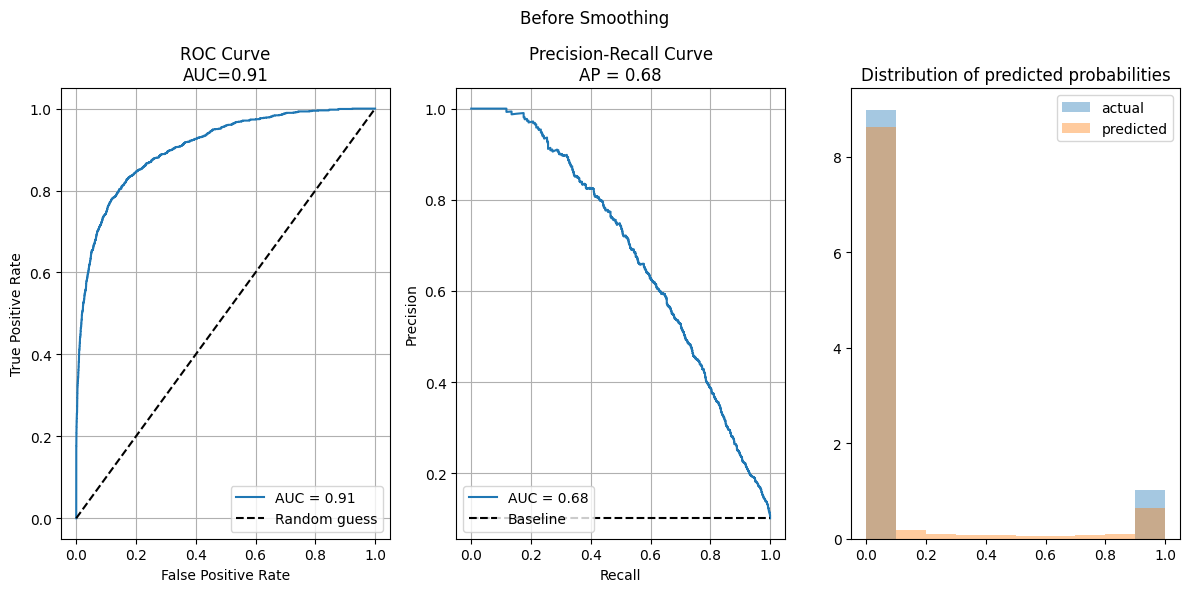

F1 0.8136384866884633


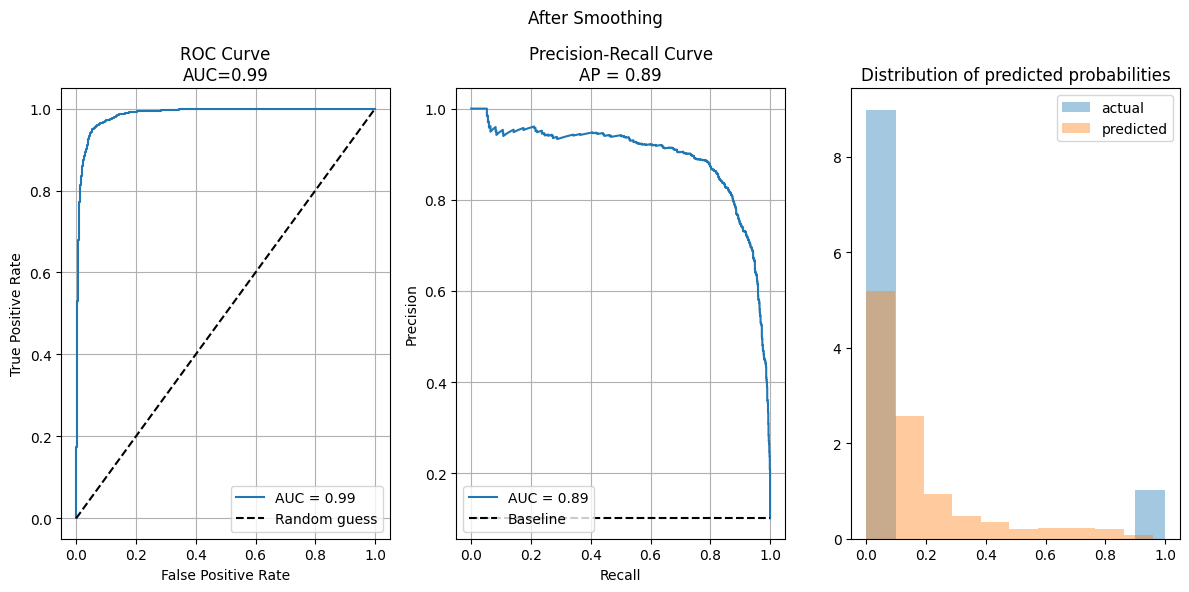

In [22]:
y_test = val_true
y_test_pred = val_scores
threshold = 0.05
y_test_pred_smooth = smooth(adjust_proba(y_test_pred, threshold), size=21)
# y_train_pred_smooth = smooth(adjust_proba(y_train_pred, threshold), size=17)
plot_roc_pr(y_test, y_test_pred, title="Before Smoothing")
plt.savefig("../plots/pres-curves_before_smoothing_camembert.pdf")
plt.show()
plot_roc_pr(y_test, y_test_pred_smooth, title="After Smoothing")
print("F1",f1_score(y_test,  (y_test_pred_smooth >0.5).astype(int)))
plt.savefig("../plots/pres-curves_after_smoothing_camembert.pdf")
plt.show()
# plot_train_test_cm(y_train, y_test, y_train_pred, y_test_pred, title="Before Smoothing")
# plot_train_test_cm(y_train, y_test, y_train_pred_smooth, y_test_pred_smooth, title="After Smoothing")

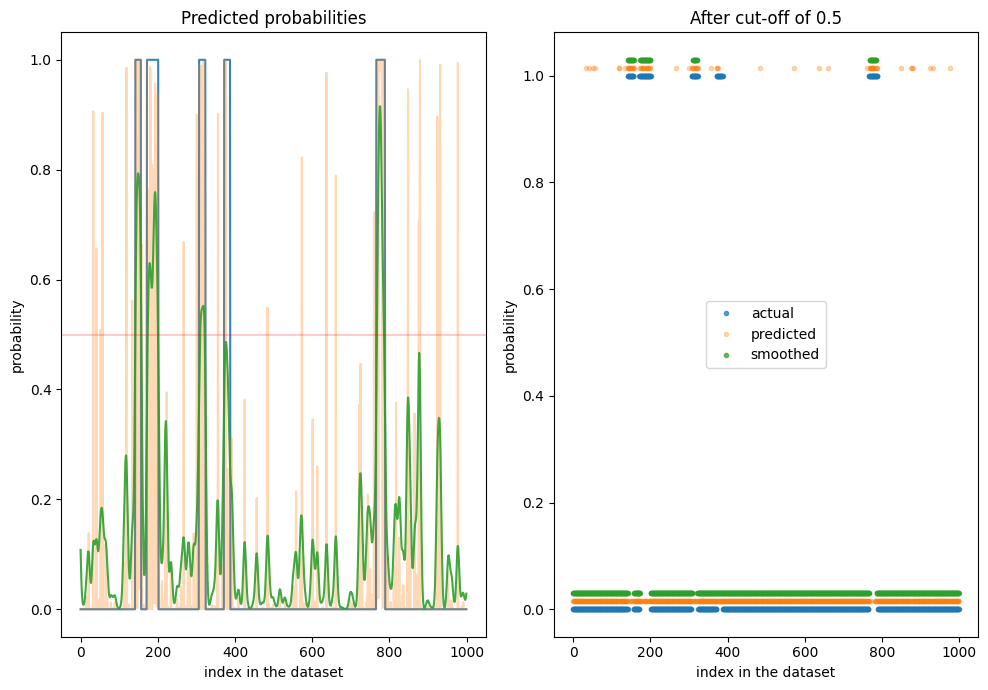

In [23]:
plot_smoothing(np.array(y_test), np.array(y_test_pred), np.array(y_test_pred_smooth),slc=slice(1000, 2000))
plt.savefig("../plots/pres-smoothing_camembert.pdf")

# SANDBOX

In [56]:
# There is a script for that now:
# MAX_EPOCHS = 7
# for epoch in range(start_epoch,MAX_EPOCHS):
#     model.train()
#     train_pred = []
#     train_true = []
#     for batch in tqdm(train_loader, desc=f"Training epoch {epoch + 1}"):
#         inputs, labels = batch
#         optimizer.zero_grad()
#         outputs = model(**inputs)
#         loss = loss_fn(outputs.logits, labels)
#         loss.backward()
#         optimizer.step()
#         with torch.no_grad():
#             train_pred.extend(outputs.logits.argmax(dim=1).cpu().numpy())
#             train_true.extend(labels.cpu().numpy())
        
#     model.eval()
#     val_scores = [] 
#     val_pred = []
#     val_true = []
    
#     with torch.no_grad():
#         for batch in tqdm(val_loader, desc=f"Evaluation epoch {epoch + 1}"):
#             inputs, labels = batch
#             outputs = model(**inputs)
#             probs = torch.sigmoid(outputs.logits[:, 1])  
#             val_scores.extend(probs.cpu().numpy())
#             val_pred.extend(outputs.logits.argmax(dim=1).cpu().numpy())
#             val_true.extend(labels.cpu().numpy())
    
#     # Confusion Matrix
#     fig, axes = plt.subplots(1,2,figsize=(10,7))
#     ConfusionMatrixDisplay.from_predictions(train_true, train_pred, ax=axes[0], colorbar=False)
#     axes[0].set_title(f"Train F1-score: {f1_score(train_true, train_pred):.2f}")

#     ConfusionMatrixDisplay.from_predictions(val_true, val_pred, ax=axes[1], colorbar=False)
#     axes[1].set_title(f"Test F1-score: {f1_score(val_true, val_pred):.2f}")
#     plt.show()
    
#     # ROC curve
#     fpr, tpr, thresholds = roc_curve(val_true, val_scores)
#     roc_auc = auc(fpr, tpr)
    
#     plt.figure(figsize=(6,6))
#     plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.3f})")
#     plt.plot([0,1], [0,1], 'k--')  # diagonal line
#     plt.xlabel("False Positive Rate")
#     plt.ylabel("True Positive Rate")
#     plt.title("ROC Curve")
#     plt.legend(loc="lower right")
#     plt.show()
    
#     if SAVE_CHECKPOINT:
#         torch.save({
#         'epoch': epoch,
#         'model_state_dict': model.state_dict(),
#         'optimizer_state_dict': optimizer.state_dict(),
#         }, FNAME)

In [57]:
# for batch in train_loader:
#     inputs_from_loader, labels = batch
#     break
# outputs = model(**inputs_from_loader)
# print(outputs.logits)

In [58]:
# inputs_from_loader

In [59]:
# inputs_from_loader["attention_mask"].shape

In [60]:
# # Minimal working example:
# from transformers import CamembertTokenizer, CamembertForSequenceClassification

# tokenizer_good = CamembertTokenizer.from_pretrained("camembert-base")
# model_good = CamembertForSequenceClassification.from_pretrained("camembert-base")

# inputs_good = tokenizer(X_train[0],
#         padding="max_length",
#         truncation=True,
#         max_length=10,
#         return_tensors="pt"
#         )

# outputs_good = model_good(**inputs_good)
# print(outputs_good.logits)
# inputs_good["attention_mask"].shape

In [61]:
# inputs_from_loader

In [62]:
# inputs_good

In [63]:
# model(**inputs_from_loader)

In [64]:
# ALL AT ONCE LOADING
# train_encodings = tokenizer(
#     X_train.tolist(),
#     padding =True,
#     truncation= True,
#     max_length=MAX_LENGTH, 
#     return_tensors="pt"
# )

# val_encodings = tokenizer(
#     X_val.tolist(),
#     padding =True,
#     truncation= True,
#     max_length=MAX_LENGTH, 
#     return_tensors="pt"
# )

# class PresidentsDataset(Dataset):
#     def __init__(self, encodings, labels):
#         self.encodings = encodings
#         self.labels = labels
    
#     def __len__(self):
#         return len(self.labels)
    
#     def __getitem__(self, idx):
#         return {key: val[idx] for key, val in self.encodings.items()}, self.labels[idx]
# train_dataset = PresidentsDataset(train_encodings, y_train)
# val_dataset = PresidentsDataset(val_encodings, y_val)